# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

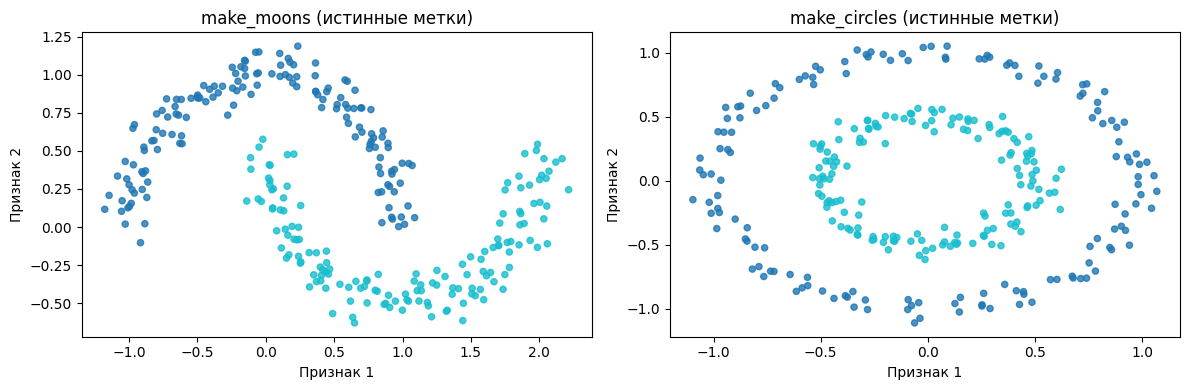

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

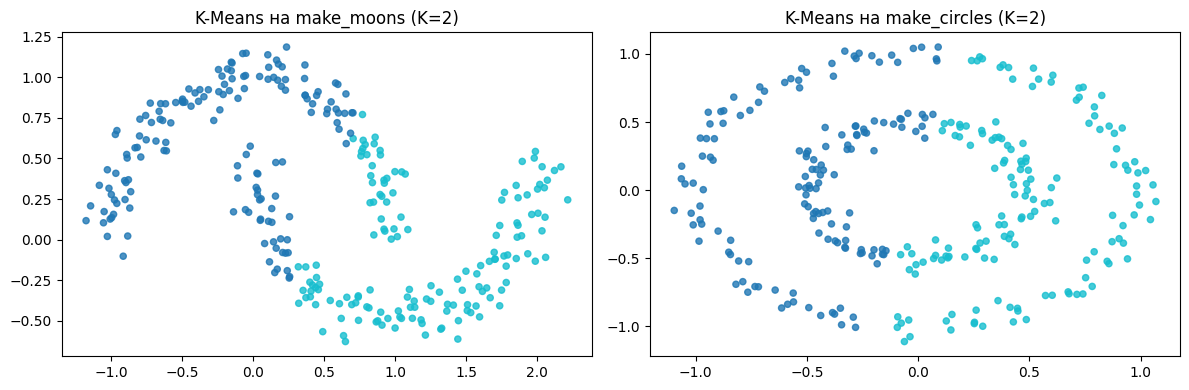

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

# 1. Создаём модели KMeans
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)

# 2. Обучаем на данных
kmeans_moons.fit(X_moons)
kmeans_circles.fit(X_circles)

# 3. Получаем метки кластеров
labels_km_moons = kmeans_moons.labels_
labels_km_circles = kmeans_circles.labels_

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

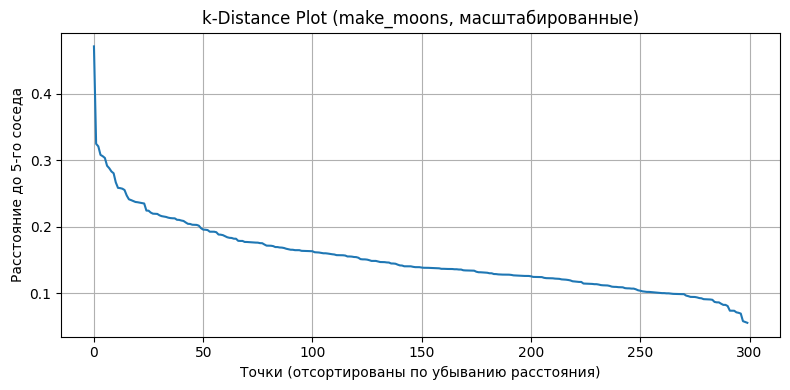

Найдите 'локоть' на графике и запишите подходящее значение eps:
Рекомендуемые кандидаты для eps: [0.2, 0.25, 0.3, 0.35]


In [6]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

# 1. Создаём и обучаем NearestNeighbors
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)

# 2. Получаем расстояния до k ближайших соседей
distances, indices = nn.kneighbors(X_moons_scaled)

# 3. Берём расстояние именно до k-го соседа (индекс k-1, т.к. нумерация с 0)
k_distances_moons = distances[:, k-1]

# 4. Сортируем по убыванию
k_distances_moons = np.sort(k_distances_moons)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")
eps_candidates = [0.2, 0.25, 0.3, 0.35]
print("Рекомендуемые кандидаты для eps:", eps_candidates)

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

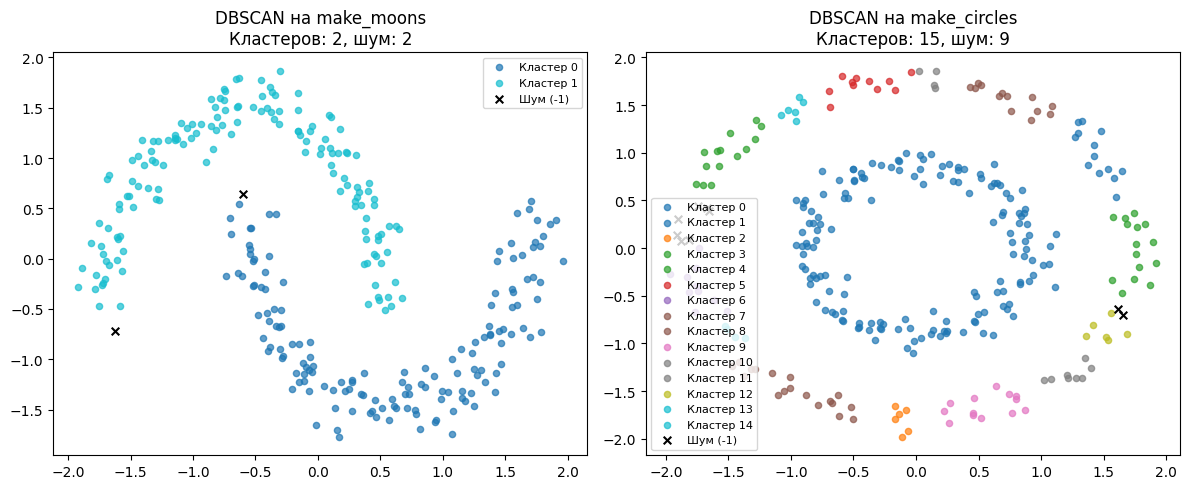

In [7]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

# Подобранные параметры (подстраивайте под ваш k-distance plot)
eps_moons = 0.25      # ← подберите по графику k-distance (обычно 0.2 - 0.3)
eps_circles = 0.22    # ← для circles обычно чуть меньше

db_moons = DBSCAN(eps=eps_moons, min_samples=5)
db_circles = DBSCAN(eps=eps_circles, min_samples=5)

# Применяем fit_predict
labels_db_moons = db_moons.fit_predict(X_moons_scaled)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [9]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

# 1. K-Means на масштабированных данных
kmeans_moons_scaled = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_kmeans_moons = kmeans_moons_scaled.fit_predict(X_moons_scaled)

# 2. Silhouette score для K-Means (на всех точках)
score_kmeans = silhouette_score(X_moons_scaled, labels_kmeans_moons)

# 3. Silhouette score для DBSCAN (только точки, не отнесённые к шуму)
if 'labels_db_moons' in locals() and len(np.unique(labels_db_moons)) > 1:
    # Исключаем шум (labels == -1)
    mask_no_noise = labels_db_moons != -1
    if mask_no_noise.sum() > 1:  # минимум 2 точки для silhouette
        score_dbscan = silhouette_score(
            X_moons_scaled[mask_no_noise], 
            labels_db_moons[mask_no_noise]
        )
    else:
        score_dbscan = None
        print("Слишком мало точек после удаления шума для расчёта silhouette")
else:
    score_dbscan = None

print("Коэффициент силуэта на make_moons")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

Коэффициент силуэта на make_moons
K-Means (K=2): 0.494
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

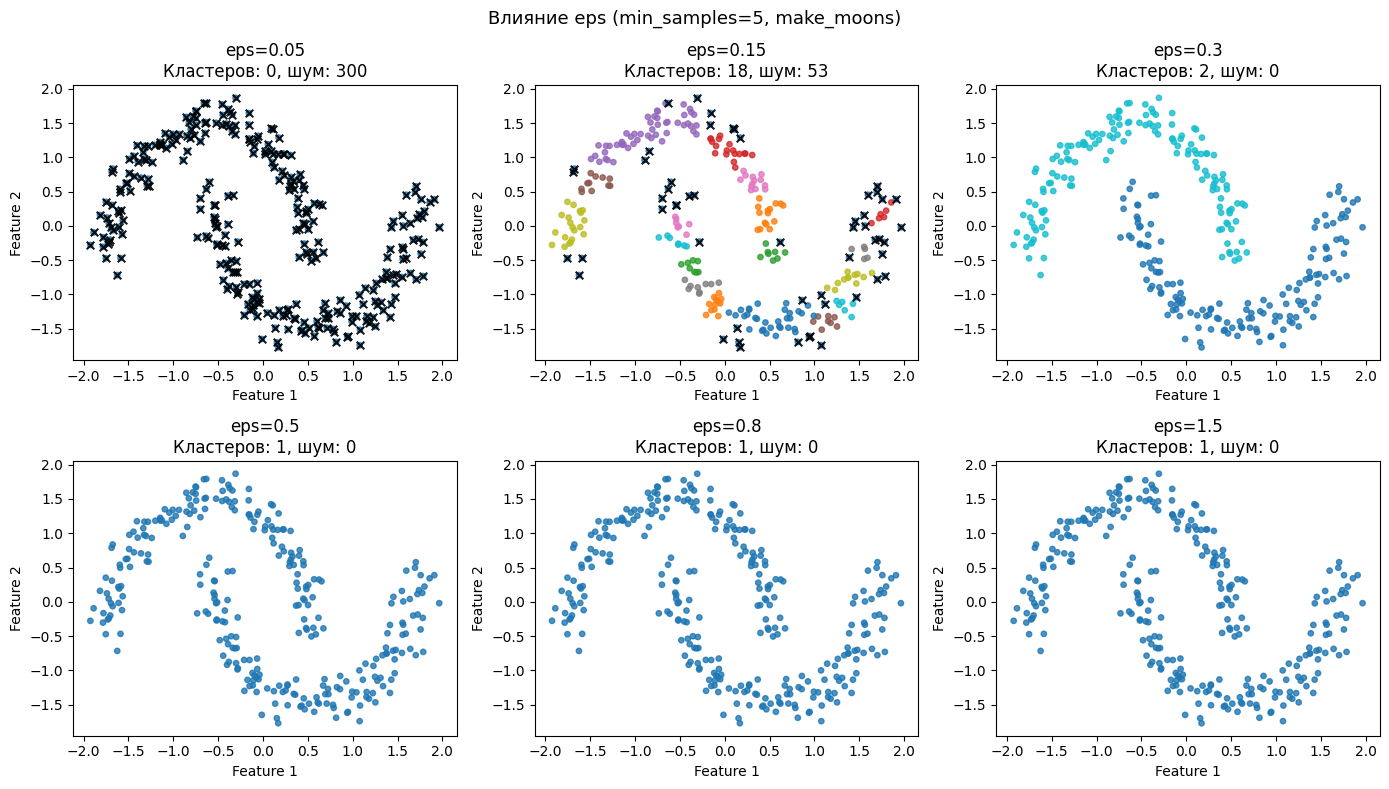

In [10]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    # YOUR CODE HERE
    dbscan = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = dbscan.fit_predict(X_moons_scaled)
    
    # Подсчёт кластеров и шума
    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    
    # Визуализация
    axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                    c=labels_i, cmap='tab10', s=15, alpha=0.8)
    
    # Отдельно рисуем шум чёрными крестиками (поверх)
    noise_mask = labels_i == -1
    if noise_mask.sum() > 0:
        axes[i].scatter(X_moons_scaled[noise_mask, 0], 
                        X_moons_scaled[noise_mask, 1],
                        s=30, c='black', marker='x', alpha=0.9)
    
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [11]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

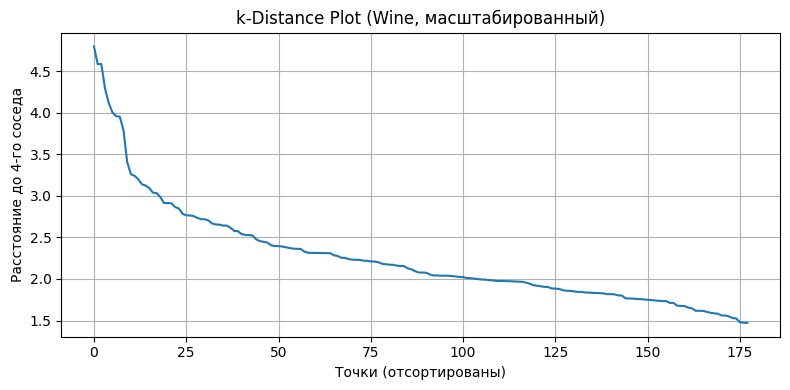

In [12]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

# 1. Масштабируем данные
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

k_wine = 4

# 2. Строим k-distance plot
nn = NearestNeighbors(n_neighbors=k_wine)
nn.fit(X_wine_scaled)

distances, _ = nn.kneighbors(X_wine_scaled)

# Берём расстояние до k-го соседа (k-1, т.к. индексация с 0)
k_dist_wine = distances[:, k_wine-1]

# Сортируем по убыванию
k_dist_wine = np.sort(k_dist_wine)[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

# Параметры (измените eps после анализа k-distance plot)
eps_wine = 2.0          # ← ПОДБЕРИТЕ по графику (обычно 1.8 - 2.5)
min_samples = 4

# Запускаем DBSCAN
dbscan_wine = DBSCAN(eps=eps_wine, min_samples=min_samples)
labels_wine = dbscan_wine.fit_predict(X_wine_scaled)

# Подсчёт статистики
n_clusters = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise = (labels_wine == -1).sum()
noise_ratio = n_noise / len(labels_wine) * 100

print("=== Результаты DBSCAN на Wine ===")
print(f"eps = {eps_wine}, min_samples = {min_samples}")
print(f"Число кластеров: {n_clusters}")
print(f"Число шумовых точек: {n_noise} ({noise_ratio:.1f}%)")
print(f"Всего точек: {len(labels_wine)}")

# Силуэт (только если есть хотя бы 2 кластера и достаточно точек без шума)
if n_clusters >= 2:
    mask_no_noise = labels_wine != -1
    if mask_no_noise.sum() > 1:
        score = silhouette_score(X_wine_scaled[mask_no_noise], labels_wine[mask_no_noise])
        print(f"Silhouette score (без шума): {score:.3f}")
    else:
        print("Недостаточно точек для расчёта silhouette score")
else:
    print("Silhouette score не вычислен (менее 2 кластеров)")

=== Результаты DBSCAN на Wine ===
eps = 2.0, min_samples = 4
Число кластеров: 6
Число шумовых точек: 66 (37.1%)
Всего точек: 178
Silhouette score (без шума): 0.221


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [19]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

# 1. Маска шумовых точек
noise_mask_wine = labels_wine == -1

# 2. Выбираем шумовые точки
X_wine_noise = X_wine[noise_mask_wine]

print("=== Анализ шумовых точек в Wine ===")
print(f"Найдено шумовых точек: {noise_mask_wine.sum()} из {len(X_wine)} "
      f"({noise_mask_wine.mean()*100:.1f}%)")

# 3. Средние значения
mean_all = X_wine.mean(axis=0)
mean_noise = X_wine_noise.mean(axis=0)

# Названия признаков
if hasattr(X_wine, 'columns'):
    feature_list = X_wine.columns.tolist()
else:
    feature_list = [f"feature_{i}" for i in range(X_wine.shape[1])]

# Создаём сравнение
comparison = pd.DataFrame({
    'Признак': feature_list,
    'Среднее по всем': mean_all,
    'Среднее по шуму': mean_noise,
    'Разница': mean_noise - mean_all,
    'Относительная разница (%)': (mean_noise - mean_all) / mean_all * 100
}).round(3)

# Выводим таблицу
print(comparison.sort_values(by='Относительная разница (%)', 
                             ascending=False, 
                             key=abs).to_string(index=False))

# 4. ТОП-5 самых отличающихся признаков
print("\nТоп-5 признаков, сильнее всего отличающихся у шумовых точек:")

# Берем abs только по числовым колонкам
numeric_cols = ['Разница', 'Относительная разница (%)']
top_diff = comparison.loc[comparison['Разница'].abs().nlargest(5).index]

for _, row in top_diff.iterrows():
    print(f"  {row['Признак']:30s}  разница = {row['Разница']:+.3f} "
          f"({row['Относительная разница (%)']:+.1f}%)")

=== Анализ шумовых точек в Wine ===
Найдено шумовых точек: 66 из 178 (37.1%)
   Признак  Среднее по всем  Среднее по шуму  Разница  Относительная разница (%)
feature_12          746.893          649.879  -97.014                    -12.989
 feature_9            5.058            4.451   -0.607                    -12.001
 feature_1            2.336            2.510    0.173                      7.420
 feature_8            1.591            1.702    0.111                      6.953
feature_10            0.957            0.985    0.027                      2.840
 feature_0           13.001           12.741   -0.260                     -1.999
 feature_3           19.495           19.845    0.351                      1.798
feature_11            2.612            2.572   -0.040                     -1.538
 feature_5            2.295            2.325    0.030                      1.309
 feature_4           99.742          100.939    1.198                      1.201
 feature_2            2.367     

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

=== Сравнение Silhouette Score на Wine ===
K-Means (n_clusters=6):     0.1690
DBSCAN (без шума):          0.2209
DBSCAN лучше


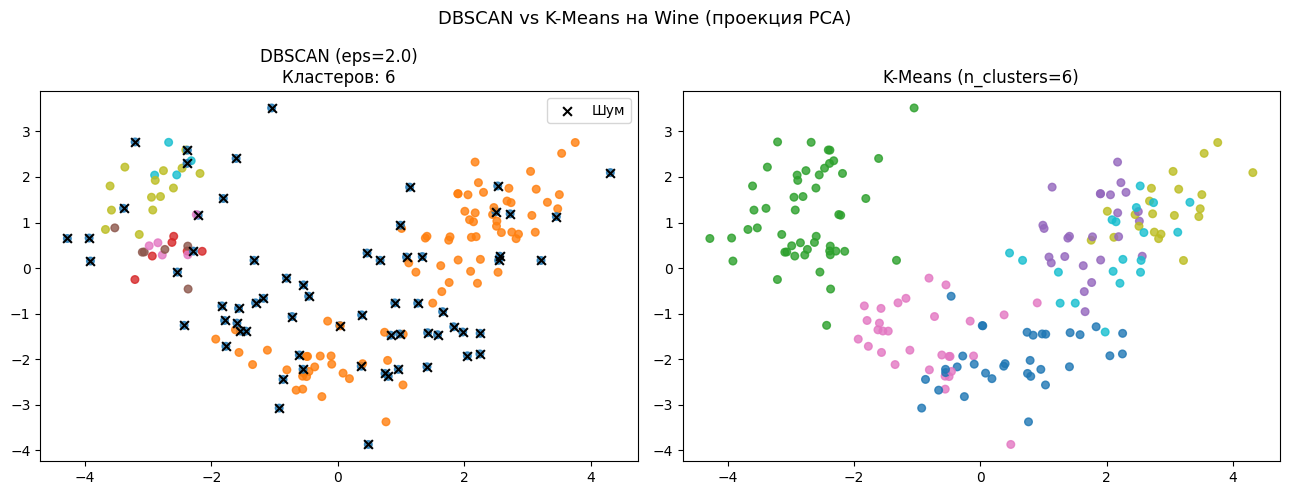

In [21]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# 1. Определяем число кластеров для KMeans
n_clusters_km = max(len(set(labels_wine)) - (1 if -1 in labels_wine else 0), 3)

kmeans_wine = KMeans(n_clusters=n_clusters_km, random_state=RANDOM_STATE)
labels_kmeans = kmeans_wine.fit_predict(X_wine_scaled)

# 2. Silhouette score для KMeans
score_kmeans = silhouette_score(X_wine_scaled, labels_kmeans)

# 3. Silhouette для DBSCAN (без шума)
mask_no_noise = labels_wine != -1
score_dbscan = None
if mask_no_noise.sum() > 1:
    score_dbscan = silhouette_score(X_wine_scaled[mask_no_noise], 
                                    labels_wine[mask_no_noise])

print("=== Сравнение Silhouette Score на Wine ===")
print(f"K-Means (n_clusters={n_clusters_km}):     {score_kmeans:.4f}")
if score_dbscan is not None:
    print(f"DBSCAN (без шума):          {score_dbscan:.4f}")
print(f"{'DBSCAN лучше' if (score_dbscan is not None and score_dbscan > score_kmeans) else 'K-Means лучше'}")

# 4. Визуализация в 2D через PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], 
                c=labels_wine, cmap='tab10', s=30, alpha=0.8)
noise_mask = labels_wine == -1
if noise_mask.sum() > 0:
    axes[0].scatter(X_wine_2d[noise_mask, 0], X_wine_2d[noise_mask, 1],
                    s=40, c='black', marker='x', label='Шум')
axes[0].set_title(f"DBSCAN (eps={eps_wine})\nКластеров: {n_clusters_km if 'n_clusters_km' in locals() else '??'}")
axes[0].legend()

# K-Means
axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], 
                c=labels_kmeans, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title(f"K-Means (n_clusters={n_clusters_km})")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN лучше работает, когда кластеры странной формы (как полумесяцы или круги) и когда в данных есть шум. Он их нормально разделяет и даже помечает выбросы как -1, а K-Means в таких случаях ломается

**2. Когда K-Means предпочтительнее?**

> K-Means лучше, если кластеры круглые и примерно одинаковые по размеру. Он быстрее, проще и даёт хороший результат на таких данных, как Wine. Плюс не оставляет шумовых точек

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN считает расстояния (eps), поэтому если признаки в разных масштабах, то один-два больших признака всё забьют, а остальные вообще не будут влиять. После StandardScaler всё становится честно

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки — это скорее всего выбросы или очень нетипичные образцы вина. У них сильно отличаются значения по alcohol, proline, flavanoids и color intensity. В реальной жизни это могут быть какие-то особенные или бракованные вина

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Не совсем честно. У DBSCAN силуэт считается без шума, а у K-Means — по всем точкам. Поэтому числа не всегда можно напрямую сравнивать, лучше смотреть ещё и на картинки